<a href="https://colab.research.google.com/github/sowmyadh1rao/Computer_Vision/blob/main/PointCloud_Construction_From_Two_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

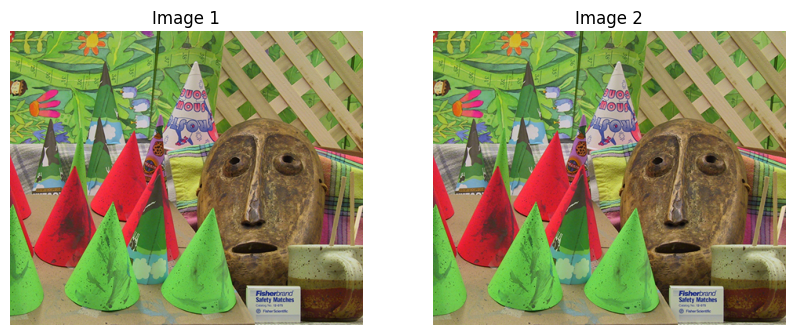

In [5]:
#Images displayed have been taken from  - Middlebury Stereo Vision Dataset - available for free download
import matplotlib.pyplot as plt
import cv2

display_img1 = cv2.imread("/content/im2.png")   # read image
display_img1 = cv2.cvtColor(display_img1, cv2.COLOR_BGR2RGB)  # convert BGR to RGB

display_img2 = cv2.imread("/content/im2.png")   # read image
display_img2 = cv2.cvtColor(display_img2, cv2.COLOR_BGR2RGB)  # convert BGR to RGB

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(display_img1)
plt.axis('off')
plt.title("Image 1")

plt.subplot(1,2,2)
plt.imshow(display_img2)
plt.axis('off')
plt.title("Image 2")

plt.show()

Keypoints: 1242
Descriptor size: (1242, 128)
Keypoints: 1199
Descriptor size: (1199, 128)
Good matches: 558
Inlier matches after RANSAC: 476
Points pt : 558
Points pt1: 558
Shape pts1: (476, 2)
Shape pts1: (476, 2)
Rotation matrix R:
 [[ 9.99584596e-01  1.76567033e-03 -2.87666067e-02]
 [-1.75920349e-03  9.99998421e-01  2.50110570e-04]
 [ 2.87670029e-02 -1.99400358e-04  9.99586124e-01]]
Translation vector t:
 [[-0.99243119]
 [-0.0113645 ]
 [-0.122275  ]]
Triangulated 3D points shape: (558, 3)


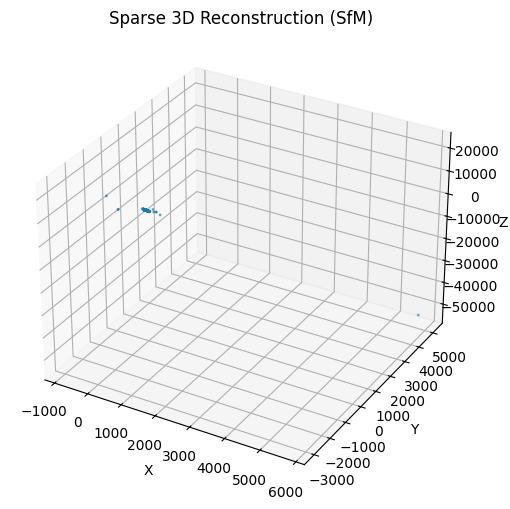

In [ ]:
import cv2

img = cv2.imread("/content/im2.png", 0)
s_img = cv2.imread("/content/im6.png",0)

sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(img, None)
keypoints1, descriptors1 = sift.detectAndCompute(s_img, None)


#print("Keypoints Deails :", keypoints)
#print("Descriptor", descriptors)
print("Keypoints:", len(keypoints))
print("Descriptor size:", descriptors.shape)


print("Keypoints:", len(keypoints1))
print("Descriptor size:", descriptors1.shape)

bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors, descriptors1, k=2)

# Lowe ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

#print("Good matches List:", good_matches)
print("Good matches:", len(good_matches))

pts = np.float32([keypoints[m.queryIdx].pt for m in good_matches])
pts1 = np.float32([keypoints1[m.trainIdx].pt for m in good_matches])

#print("Point List 1:",pts)
#print("Point List 2:",pts1)

H, mask = cv2.findHomography(pts, pts1, cv2.RANSAC, 5.0)

inlier_matches = [good_matches[i] for i in range(len(good_matches)) if mask[i]]

import numpy as np

# pts1, pts2 are coordinates of keypoints in image1 and image2
s_pts = np.float32([keypoints[m.queryIdx].pt for m in inlier_matches])
s_pts1 = np.float32([keypoints1[m.trainIdx].pt for m in inlier_matches])

print("Points pt :",len(pts))
print("Points pt1:",len(pts1))

h, w = img.shape
fx = fy = 800  # focal length in pixels (example)
cx = w / 2
cy = h / 2
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]])

print("Shape pts1:", s_pts.shape)
print("Shape pts1:", s_pts1.shape)


E, mask_pose = cv2.findEssentialMat(s_pts, s_pts1, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)

_, R, t, mask_pose = cv2.recoverPose(E, s_pts, s_pts1, K)

print("Rotation matrix R:\n", R)
print("Translation vector t:\n", t)

pts1_norm = cv2.undistortPoints(pts.reshape(-1,1,2), K, None)
pts2_norm = cv2.undistortPoints(pts1.reshape(-1,1,2), K, None)

P1 = np.hstack((np.eye(3), np.zeros((3,1))))  # Camera 1 at origin
P2 = np.hstack((R, t))                        # Camera 2 relative pose

pts4D_h = cv2.triangulatePoints(P1, P2, pts1_norm, pts2_norm)
pts3D = pts4D_h[:3] / pts4D_h[3]  # Convert to Euclidean coordinates
pts3D = pts3D.T
print("Triangulated 3D points shape:", pts3D.shape)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts3D[:,0], pts3D[:,1], pts3D[:,2], s=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Sparse 3D Reconstruction (SfM)")
plt.show()


In [ ]:
#Point cloud consruction done